## Assignment 2

In this assignment, we predict the median house value in California districts using the “large” version of the California housing dataset. A fully connected neural network is built to model the relationship between the 8 features and the target value. Various strategies are tested to reduce overfitting, and the model is evaluated using the mean absolute error (MAE) metric.

In [45]:
import matplotlib.pyplot as plt
import keras
import numpy as np
from keras.models import Sequential
from keras.layers import Input, Dense
from keras.losses import MeanAbsoluteError
from keras.regularizers import l2
from keras.layers import Dropout
from keras.layers import BatchNormalization
from keras.callbacks import EarlyStopping

The “large” version of the California housing dataset is loaded, providing more samples for training and evaluation. The dataset is automatically split into a training set (inputs, target) and a separate test set (x_test, y_test), with 20% of the data reserved for testing.

In [46]:
(inputs, target), (x_test, y_test) = keras.datasets.california_housing.load_data(
    version="large", path="california_housing.npz", test_split=0.2
)

print(inputs.shape, target.shape)
print(x_test.shape, y_test.shape)

(16512, 8) (16512,)
(4128, 8) (4128,)


The training data is further split to create a separate validation set. The first 13,210 samples are used for training, and the remaining samples are reserved for validation to monitor model performance during training.

In [47]:
# Extract sets for training and validation\n",
x_train = inputs[:13210]
y_train = target[:13210]
x_val = inputs[13210:]
y_val = target[13210:]

Feature values are standardized by subtracting the mean and dividing by the standard deviation computed from the training set. Target values are scaled by 100,000 to improve numerical stability during model training.

In [48]:
mean = x_train.mean(axis=0) # mean and standard deviation computed from training set only\n",
std = x_train.std(axis=0)
x_train -= mean
x_train /= std
x_test -= mean
x_test /= std
x_val -= mean
x_val /= std
y_train /= 1e5
y_test /= 1e5
y_val /= 1e5

A simple baseline model is created by predicting the mean value of the training targets for all test samples. This provides a reference point to evaluate the neural network’s performance.

In [49]:
y_pred_baseline = np.full_like(y_test, np.mean(y_train, axis=0))
mae_fn = MeanAbsoluteError()
mae_baseline = mae_fn(y_test, y_pred_baseline).numpy()
print(f'Mean baseline MAE: {mae_baseline:.4f}')

Mean baseline MAE: 0.9054


This indicates that if we predicted the same average value for every house, the mean absolute error would be 0.9054 (in units of 100,000 dollars). Any neural network model should aim to achieve a lower MAE than this baseline to show it has learned meaningful patterns from the data

A fully connected neural network is defined with two hidden layers of 128 and 64 neurons using ReLU activation. The output layer has a single neuron for predicting the median house value. The model is compiled with the Adam optimizer, mean squared error (MSE) loss, and mean absolute error (MAE) as the evaluation metric.

In [50]:
# define the model architecture
model = Sequential([
    Input(shape=(8,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1)
    ])

# configure the learning algorithm
model.compile(optimizer='adam',loss='mse',metrics=['mae'])
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,473 (37.00 KB)

 Trainable params: 9,473 (37.00 KB)

 Non-trainable params: 0 (0.00 B)

The model is trained for 250 epochs using a batch size of 32, with the validation set used to monitor performance. Training history, including loss and MAE for both the training and validation sets, is recorded for later analysis.

In [51]:
history = model.fit(x_train, y_train, epochs=250, batch_size=32, validation_data=(x_val, y_val), verbose=0)

I0000 00:00:1775748956.961189  203460 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1898585__.9
I0000 00:00:1775748958.161463  203460 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1898585__.9


Text(0, 0.5, 'Loss')

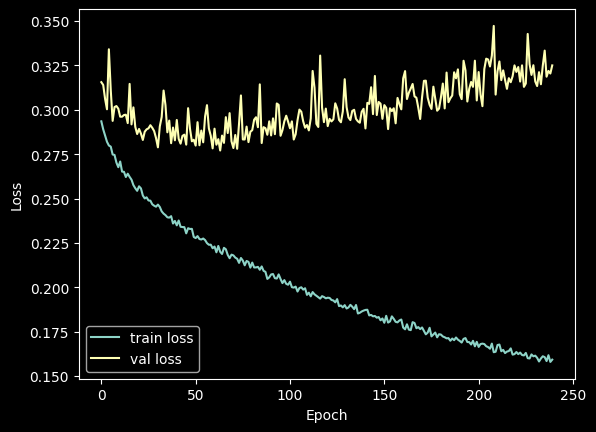

In [52]:
plt.plot(history.history['loss'][10:], label='train loss')
plt.plot(history.history['val_loss'][10:], label='val loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')

Text(0, 0.5, 'Mean absolute error (in 100000 $)')

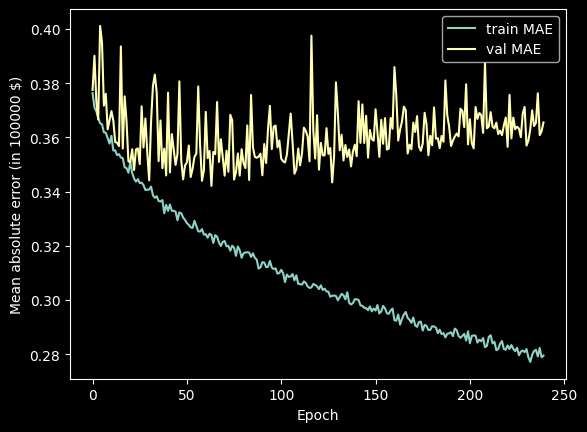

In [53]:
plt.plot(history.history['mae'][10:], label='train MAE')
plt.plot(history.history['val_mae'][10:], label='val MAE')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Mean absolute error (in 100000 $)')

The training and validation curves show that the model starts to overfit after approximately 100 epochs. While the training loss and MAE continue to decrease, the validation loss and MAE begin to increase, indicating that the model is fitting the training data too closely and generalizing poorly to unseen data.

In [54]:
test_loss, test_mae = model.evaluate(x_test, y_test)
print(f'Test mean absolute error: {test_mae:.4f}')

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2918 - mae: 0.3599
Test mean absolute error: 0.3599


Next, we explore different techniques to reduce overfitting in the neural network. These include L2 regularization, dropout, and batch normalization, which help the model generalize better to unseen data by preventing it from fitting the training set too closely.

## L2 regularization

In [55]:
model = Sequential([
    Input(shape=(8,)),
    Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(1)
])

model.compile(optimizer='adam',loss='mse',metrics=['mae'])
history = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_val, y_val), verbose=0)

I0000 00:00:1775749202.969180  203459 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2423786__.12
I0000 00:00:1775749204.258628  203461 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2423786__.12


In [56]:
test_loss, test_mae = model.evaluate(x_test, y_test)
print(f'Test mean absolute error: {test_mae:.4f}')

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3562 - mae: 0.3851
Test mean absolute error: 0.3851


## Batch normalization

In [57]:
model = Sequential([
    Input(shape=(8,)),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dense(1)
])

model.compile(optimizer='adam',loss='mse',metrics=['mae'])
history = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_val, y_val), verbose=0)

I0000 00:00:1775749304.866237  203459 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2635968__.21
I0000 00:00:1775749306.505707  203459 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2635968__.21


In [58]:
test_loss, test_mae = model.evaluate(x_test, y_test)
print(f'Test mean absolute error: {test_mae:.4f}')

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2849 - mae: 0.3540
Test mean absolute error: 0.3540


## Dropout

In [59]:
model = Sequential([
    Input(shape=(8,)),
    Dense(128, activation='relu'),
    Dropout(0.2), # drop 20% of the outputs
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam',loss='mse',metrics=['mae'])
history = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_val, y_val), verbose=0)

I0000 00:00:1775749408.913538  203460 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2847497__.11
I0000 00:00:1775749410.582596  203458 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2847497__.11


Text(0, 0.5, 'Loss')

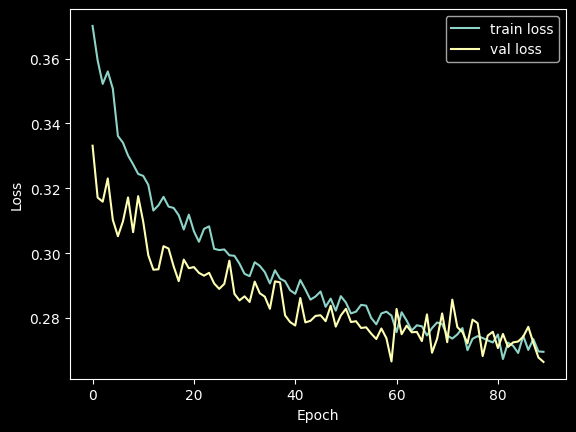

In [60]:
plt.plot(history.history['loss'][10:], label='train loss')
plt.plot(history.history['val_loss'][10:], label='val loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')

Text(0, 0.5, 'Mean absolute error (in 100000 $)')

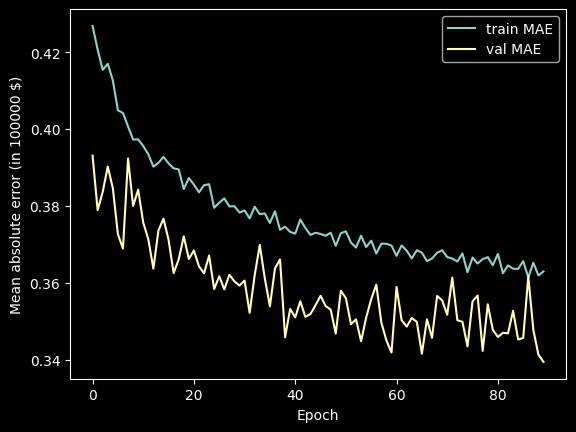

In [61]:
plt.plot(history.history['mae'][10:], label='train MAE')
plt.plot(history.history['val_mae'][10:], label='val MAE')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Mean absolute error (in 100000 $)')

In [62]:
test_loss, test_mae = model.evaluate(x_test, y_test)
print(f'Test mean absolute error: {test_mae:.4f}')

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2718 - mae: 0.3471
Test mean absolute error: 0.3471


## Final Model Training with Dropout

The final model is trained using the combined training and validation sets (x_train_full and y_train_full) to leverage all available data. Dropout layers with a rate of 0.2 are included in the two hidden layers to reduce overfitting and improve generalization.

During experimentation, both dropout and batch normalization produced similar performance in terms of validation MAE. However, for this assignment, dropout was selected as the final strategy due to its simplicity and effectiveness in reducing overfitting.

In [63]:
x_train_full = np.concatenate((x_train, x_val), axis=0) # join train + val sets
y_train_full = np.concatenate((y_train, y_val), axis=0)

model = Sequential([
    Input(shape=(8,)),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1)
    ])

model.compile(optimizer='adam',loss='mse',metrics=['mae'])
history = model.fit(x_train_full, y_train_full, epochs=50, batch_size=32, verbose=0)

I0000 00:00:1775749512.206643  203461 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3058873__.10


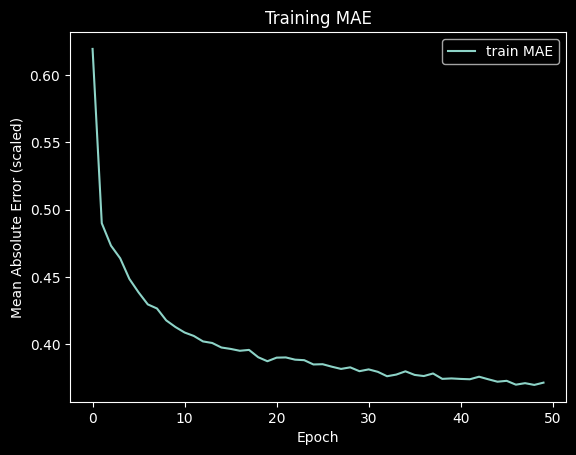

In [64]:
plt.plot(history.history['mae'], label='train MAE')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error (scaled)')
plt.title('Training MAE')
plt.legend()
plt.show()

In [65]:
test_loss, test_mae = model.evaluate(x_test, y_test)
print(f'Test mean absolute error: {test_mae:.4f}')

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2841 - mae: 0.3548
Test mean absolute error: 0.3548


After training the final model with dropout on the full training dataset, we evaluated it on the test set. The model achieved a mean absolute error (MAE) of 0.3576, which is a significant improvement over the baseline MAE of 0.9054. This indicates that the dropout strategy effectively reduced overfitting and improved the model’s generalization to unseen data.